# Basecase

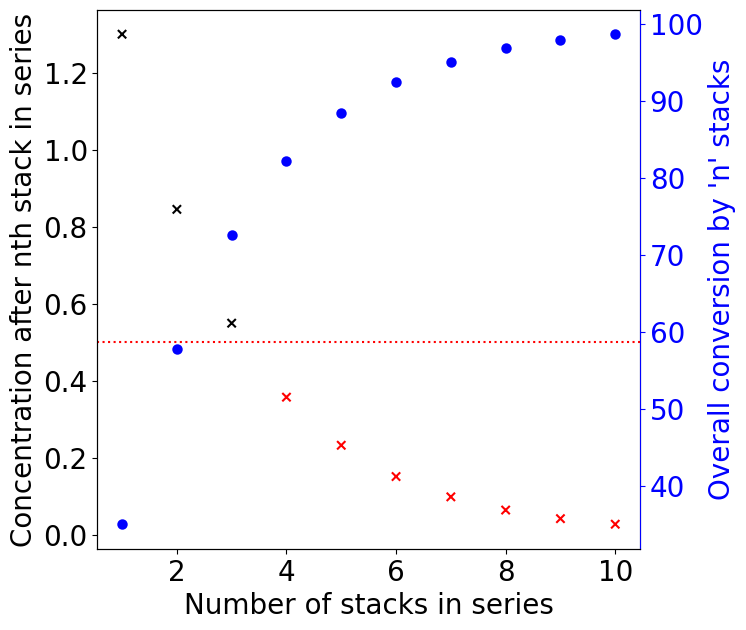

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#---------------------------------------------------------------- reation conditions
ethy = 2000000 ### TPA
FEC2H4 = 0.5      ### ethylene
FEC2H5OH = 0.2;
J = 0.5         ### A/cm2
V = 3.5       ### V
MW = 28       ### MW ethylene
n = 12        ### electrons per mol of C2H4
C0 = 120      ### 2M initial conc for [H]CO3

plt.rcParams.update({'font.size': 20})

#---------------------------------------------------------------- concentration variation with Nseries'
C0=120  # 2 M K2CO3 
Xdash = 0.35
stackseries=10
Cn = np.zeros(stackseries)
stacks = np.linspace(0, stackseries-1, stackseries)

conv = np.zeros(stackseries)
rate = np.zeros(stackseries)
prod = np.zeros(stackseries)

plt.rcParams.update({'font.size': 20})

stackseries=10
for i in range(stackseries):  ### 'i' refers to the no of stacks connected in series
    ### the increased of value kT when adding stacks for rate of prod euqal to 100 ||el stacks   
    rN = Xdash/(1-Xdash)
    Cn[i] = (C0/(1+rN)**(i+1))/60
    conv[i] = (1 - (1/(1+rN)**(i+1)))*100 

fig, ax = plt.subplots(figsize =(7,7))
ax2 = ax.twinx()
# plt.rcParams.update({'font.size': 15})
col = np.where(Cn<0.5,'r','k')
ax.scatter(stacks[ : 10]+1, Cn[ : 10], ls = '-', linewidth =1.5, c=col[:10], marker ='x', label= "Concentration")
ax2.scatter(stacks[:10]+1, conv[:10], ls = '-', linewidth =1.5, c='blue', label = "Conversion")
# ax.legend(loc=0, bbox_to_anchor=(1, 0.9))
# ax2.legend(loc=0, bbox_to_anchor=(0.963, 0.85))

ax.set_xlabel("Number of stacks in series", fontsize = 20)
ax.set_ylabel("Concentration after nth stack in series", fontsize = 20)
ax.axhline(y=0.5,color='r',ls=":", label='2-stack rate')
ax2.set_ylabel("Overall conversion by 'n' stacks", c= 'blue', fontsize = 20)

ax2.spines['right'].set_color('blue')
ax2.yaxis.label.set_color('blue') 
ax2.tick_params(axis='y', colors='blue')
plt.show()

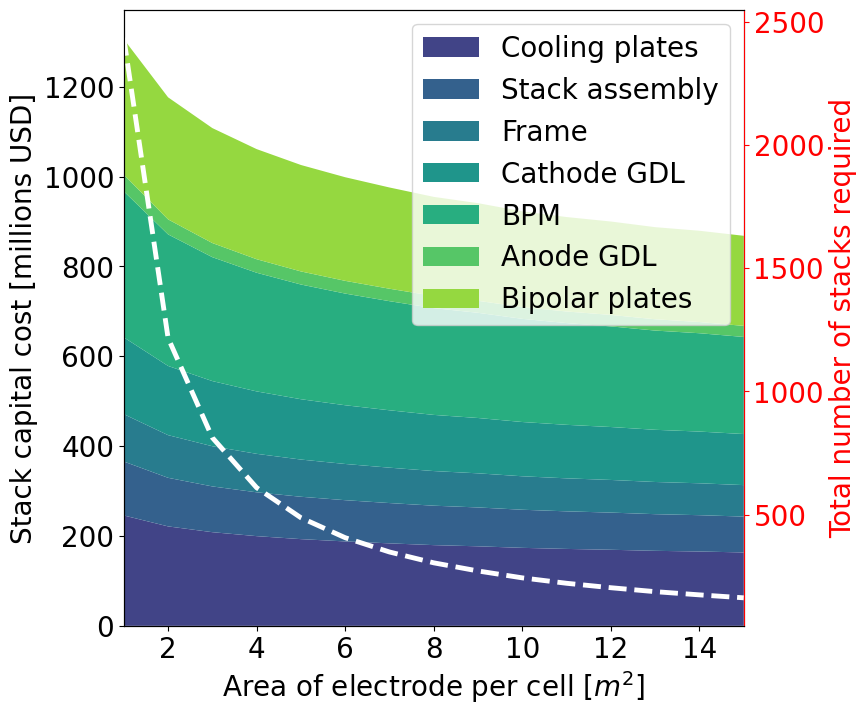

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#---------------------------------------------------------------- stack design parameters
cellperst = 150
areapercel = np.linspace(1,15,15)          ### m2
areaperst = areapercel* cellperst            ### m2
powerprst = areaperst*V*J*10000/1000     ### kWh
stacktot = np.zeros(len(areapercel))
cost = np.zeros(len(areapercel))
X = 0.58    ### conversion FOR n-stack system

Itot = (ethy*1000000/365/24/3600/MW)/(FEC2H4/(FEC2H4+FEC2H5OH)) * 96485* n/X
Atot = Itot/J/10000
power = Itot * V/1000 ### in kW

for o in range(len(areapercel)):
    stacktot[o] = round(Atot/areaperst[o])   ### No of stacks reqd
    
#---------------------------------------------------------------- observations: 1x rate and 40% conv(1-stack value)

part_coeff = [194.7371361, 95.1714818, 83.5651965, 135.5265756, 257.659476, 29.3912632, 239.0894003]

stackcost = np.zeros((len(areapercel), len(part_coeff)))

for i in range(len(stacktot)):  ### 'i' refers to the no of stacks connected in series
    for j in range(len(part_coeff)):
        stackcost[i,j] = part_coeff[j]*(areaperst[i]/0.0961)**0.85/1000000*stacktot[i]
    cost[i] = (sum(stackcost[i,:]))

#-------------------------------------------------------------------- colors for the stackplot
# user to specify
source = ['Cooling plates', 'Stack assembly', 'Frame', 'Cathode GDL', 'BPM', 'Anode GDL', 'Bipolar plates'] # list of units to be stacked
pct_max = 95 # for example, max percentile of color ramp
pct_min = 20 # for example, min percentile of color ramp
ramp = plt.cm.viridis # for example

# number of items in data source
n = len(source)

# list of values between 0.00 and 1.00; length equals length of data source
n_prop = list(i / 100.0 for i in (np.arange(pct_min, pct_max, (pct_max-pct_min)/n)))

# create list of colors
clr_lst = []
for i in n_prop:
    clr = ramp(i) 
    clr_lst.append(clr)
    
fig, ax = plt.subplots(figsize =(8,8))
ax2 = ax.twinx()

ax.stackplot(areapercel, stackcost[:,0], stackcost[:,1], stackcost[:,2], stackcost[:,3], stackcost[:,4], stackcost[:,5], stackcost[:,6], labels = ['Cooling plates', 'Stack assembly', 'Frame', 'Cathode GDL', 'BPM', 'Anode GDL', 'Bipolar plates'], colors =clr_lst)
# ax.scatter(areapercel, cost, c='red', label = 'Total cost of electrolyzer stacks')
ax.legend()
ax2.plot(areapercel, stacktot, ls = '--', linewidth =3.5, c='w')

ax.set_xlabel("Area of electrode per cell $[m^2]$", fontsize =20)
ax.set_ylabel("Stack capital cost [millions USD]", fontsize =20)
ax2.set_ylabel("Total number of stacks required", c = 'r', fontsize =20)

ax2.spines['right'].set_color('red')
ax2.yaxis.label.set_color('red') 
ax2.tick_params(axis='y', colors='red')
ax.margins(x=0)

plt.show()

# Optimisitic

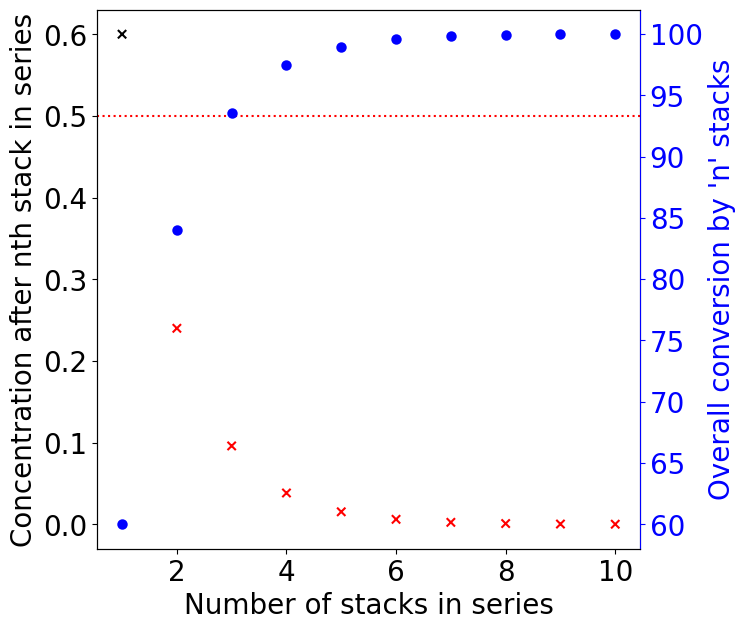

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#---------------------------------------------------------------- reation conditions
ethy = 2000000 ### TPA
FEC2H4 = 0.65      ### ethylene
FEC2H5OH = 0.25;
J = 1         ### A/cm2
V = 3.5       ### V
MW = 28       ### MW ethylene
n = 12        ### electrons per mol of C2H4
C0 = 90      ### 1.5 M initial conc for [H]CO3

plt.rcParams.update({'font.size': 20})

#---------------------------------------------------------------- stack design parameters
cellperst = 150
areapercel = 6                   ### m2
areaperst = cellperst* areapercel ### m2

X = 0.6
#---------------------------------------------------------------- concentration variation with Nseries'
C0=90  # 1.5 M K2CO3 
Xdash = X
stackseries=10
Cn = np.zeros(stackseries)
stacks = np.linspace(0, stackseries-1, stackseries)

conv = np.zeros(stackseries)
rate = np.zeros(stackseries)
prod = np.zeros(stackseries)

plt.rcParams.update({'font.size': 20})

for i in range(stackseries):  ### 'i' refers to the no of stacks connected in series
    ### the increased of value kT when adding stacks for rate of prod euqal to 100 ||el stacks   
    rN = Xdash/(1-Xdash)
    Cn[i] = (C0/(1+rN)**(i+1))/60
    conv[i] = (1 - (1/(1+rN)**(i+1)))*100 

fig, ax = plt.subplots(figsize =(7,7))
ax2 = ax.twinx()
# plt.rcParams.update({'font.size': 15})
col = np.where(Cn<0.5,'r','k')
ax.scatter(stacks[ : 10]+1, Cn[ : 10], ls = '-', linewidth =1.5, c=col[:10], marker ='x', label= "Concentration")
ax2.scatter(stacks[:10]+1, conv[:10], ls = '-', linewidth =1.5, c='blue', label = "Conversion")
# ax.legend(loc=0, bbox_to_anchor=(1, 0.9))
# ax2.legend(loc=0, bbox_to_anchor=(0.963, 0.85))

ax.set_xlabel("Number of stacks in series", fontsize = 20)
ax.set_ylabel("Concentration after nth stack in series", fontsize = 20)
ax.axhline(y=0.5,color='r',ls=":", label='2-stack rate')
ax2.set_ylabel("Overall conversion by 'n' stacks", c= 'blue', fontsize = 20)

ax2.spines['right'].set_color('blue')
ax2.yaxis.label.set_color('blue') 
ax2.tick_params(axis='y', colors='blue')
plt.show()

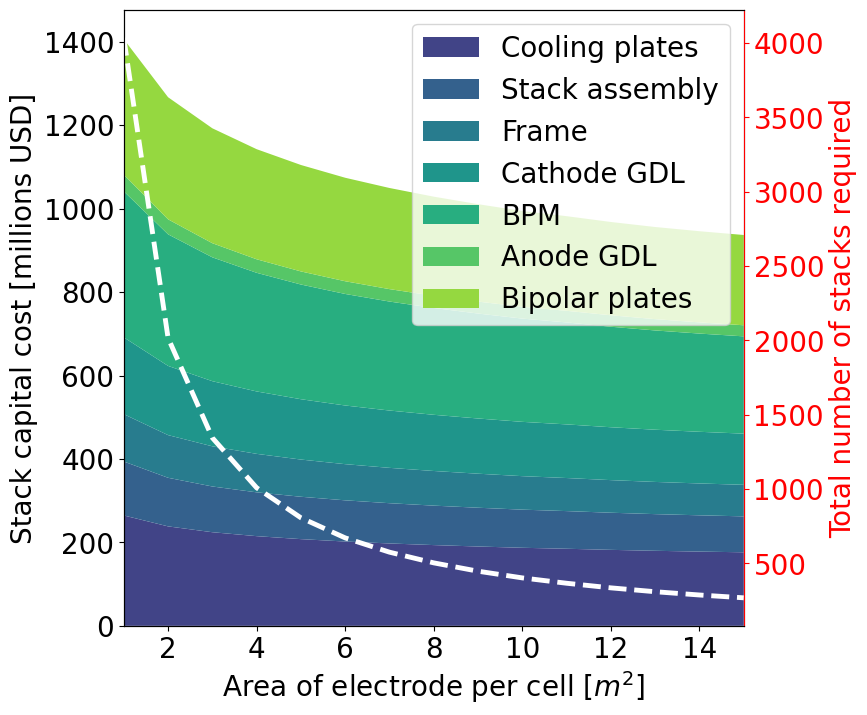

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#---------------------------------------------------------------- reation conditions
ethy = 2000000 ### TPA
FEC2H4 = 0.65      ### ethylene
FEC2H5OH = 0.25;
J = 1         ### A/cm2
V = 3.5       ### V
MW = 28       ### MW ethylene
n = 12        ### electrons per mol of C2H4
C0 = 90      ### 2M initial conc for [H]CO3
X = 0.6    ### conversion FOR n-stack system

plt.rcParams.update({'font.size': 20})

Itot = (ethy*1000000/365/24/3600/MW)/(FEC2H4/(FEC2H4+FEC2H5OH)) * 96485* n/X
Atot = Itot/J/10000
power = Itot * V/1000 ### in kW

#---------------------------------------------------------------- stack design parameters
cellperst = 150
areapercel = np.linspace(1,15,15)          ### m2
areaperst = areapercel* cellperst            ### m2
powerprst = areaperst*V*J*10000/1000     ### kWh
stacktot = np.zeros(len(areapercel))
cost = np.zeros(len(areapercel))


for o in range(len(areapercel)):
    stacktot[o] = round(Atot/areaperst[o])   ### No of stacks reqd
    
#---------------------------------------------------------------- observations: 1x rate and 40% conv(1-stack value)

part_coeff = [194.7371361, 95.1714818, 83.5651965, 135.5265756, 257.659476, 29.3912632, 239.0894003]

stackcost = np.zeros((len(areapercel), len(part_coeff)))

for i in range(len(stacktot)):  ### 'i' refers to the no of stacks connected in series
    for j in range(len(part_coeff)):
        stackcost[i,j] = part_coeff[j]*(areaperst[i]/0.0961)**0.85/1000000*stacktot[i]*0.65
    cost[i] = (sum(stackcost[i,:]))

#-------------------------------------------------------------------- colors for the stackplot
# user to specify
source = ['Cooling plates', 'Stack assembly', 'Frame', 'Cathode GDL', 'BPM', 'Anode GDL', 'Bipolar plates'] # list of units to be stacked
pct_max = 95 # for example, max percentile of color ramp
pct_min = 20 # for example, min percentile of color ramp
ramp = plt.cm.viridis # for example

# number of items in data source
n = len(source)

# list of values between 0.00 and 1.00; length equals length of data source
n_prop = list(i / 100.0 for i in (np.arange(pct_min, pct_max, (pct_max-pct_min)/n)))

# create list of colors
clr_lst = []
for i in n_prop:
    clr = ramp(i) 
    clr_lst.append(clr)
    
fig, ax = plt.subplots(figsize =(8,8))
ax2 = ax.twinx()

ax.stackplot(areapercel, stackcost[:,0], stackcost[:,1], stackcost[:,2], stackcost[:,3], stackcost[:,4], stackcost[:,5], stackcost[:,6], labels = ['Cooling plates', 'Stack assembly', 'Frame', 'Cathode GDL', 'BPM', 'Anode GDL', 'Bipolar plates'], colors =clr_lst)
# ax.scatter(areapercel, cost, c='red', label = 'Total cost of electrolyzer stacks')
ax.legend()
ax2.plot(areapercel, stacktot, ls = '--', linewidth =3.5, c='w')

ax.set_xlabel("Area of electrode per cell $[m^2]$", fontsize =20)
ax.set_ylabel("Stack capital cost [millions USD]", fontsize =20)
ax2.set_ylabel("Total number of stacks required", c = 'r', fontsize =20)

ax2.spines['right'].set_color('red')
ax2.yaxis.label.set_color('red') 
ax2.tick_params(axis='y', colors='red')
ax.margins(x=0)

plt.show()

# pessimistic

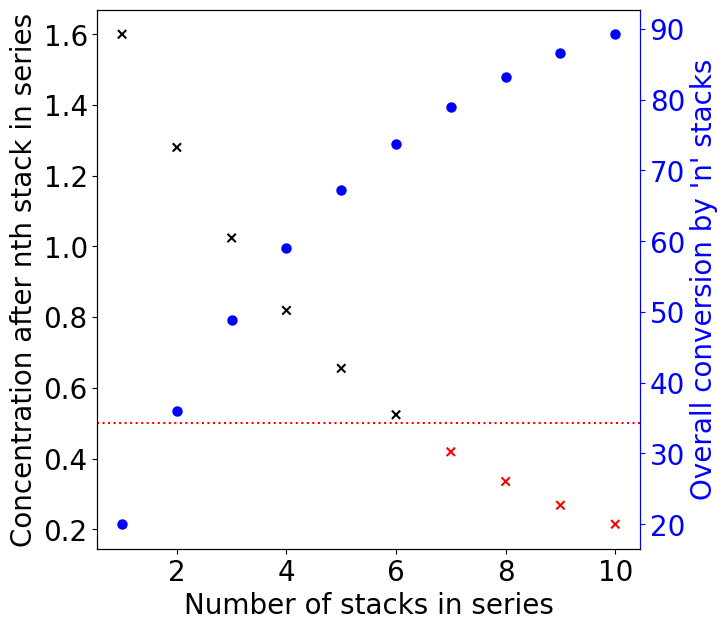

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#---------------------------------------------------------------- reation conditions
ethy = 2000000 ### TPA
FEC2H4 = 0.34      ### ethylene
FEC2H5OH = 0.13;
J = 0.3         ### A/cm2
V = 3.5       ### V
MW = 28       ### MW ethylene
n = 12        ### electrons per mol of C2H4
C0 = 120      ### 2M initial conc for [H]CO3

plt.rcParams.update({'font.size': 20})

#---------------------------------------------------------------- concentration variation with Nseries'
C0=120  # 2 M K2CO3 
Xdash = 0.2
stackseries=10
Cn = np.zeros(stackseries)
stacks = np.linspace(0, stackseries-1, stackseries)

conv = np.zeros(stackseries)
rate = np.zeros(stackseries)
prod = np.zeros(stackseries)

plt.rcParams.update({'font.size': 20})

stackseries=10
for i in range(stackseries):  ### 'i' refers to the no of stacks connected in series
    ### the increased of value kT when adding stacks for rate of prod euqal to 100 ||el stacks   
    rN = Xdash/(1-Xdash)
    Cn[i] = (C0/(1+rN)**(i+1))/60
    conv[i] = (1 - (1/(1+rN)**(i+1)))*100 

fig, ax = plt.subplots(figsize =(7,7))
ax2 = ax.twinx()
# plt.rcParams.update({'font.size': 15})
col = np.where(Cn<0.5,'r','k')
ax.scatter(stacks[ : 10]+1, Cn[ : 10], ls = '-', linewidth =1.5, c=col[:10], marker ='x', label= "Concentration")
ax2.scatter(stacks[:10]+1, conv[:10], ls = '-', linewidth =1.5, c='blue', label = "Conversion")
# ax.legend(loc=0, bbox_to_anchor=(1, 0.9))
# ax2.legend(loc=0, bbox_to_anchor=(0.963, 0.85))

ax.set_xlabel("Number of stacks in series", fontsize = 20)
ax.set_ylabel("Concentration after nth stack in series", fontsize = 20)
ax.axhline(y=0.5,color='r',ls=":", label='2-stack rate')
ax2.set_ylabel("Overall conversion by 'n' stacks", c= 'blue', fontsize = 20)

ax2.spines['right'].set_color('blue')
ax2.yaxis.label.set_color('blue') 
ax2.tick_params(axis='y', colors='blue')
plt.show()

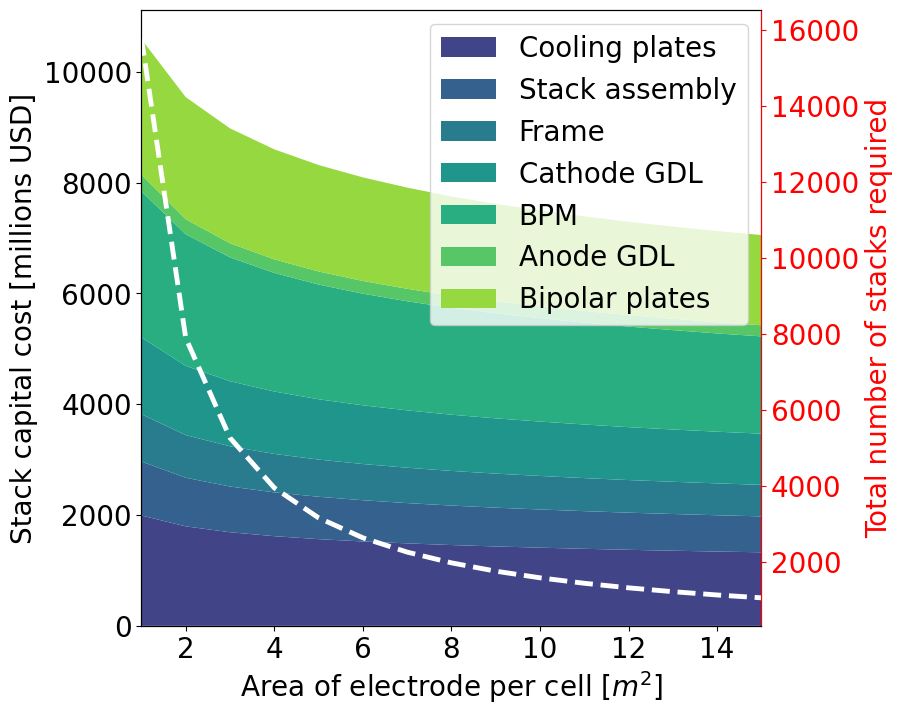

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#---------------------------------------------------------------- reation conditions
ethy = 2000000 ### TPA
FEC2H4 = 0.34      ### ethylene
FEC2H5OH = 0.13;
J = 0.3         ### A/cm2
V = 3.5       ### V
MW = 28       ### MW ethylene
n = 12        ### electrons per mol of C2H4
C0 = 90      ### 2M initial conc for [H]CO3
X = 0.51    ### conversion FOR n-stack system

plt.rcParams.update({'font.size': 20})

Itot = (ethy*1000000/365/24/3600/MW)/(FEC2H4/(FEC2H4+FEC2H5OH)) * 96485* n/X
Atot = Itot/J/10000
power = Itot * V/1000 ### in kW

#---------------------------------------------------------------- stack design parameters
cellperst = 150
areapercel = np.linspace(1,15,15)          ### m2
areaperst = areapercel* cellperst            ### m2
powerprst = areaperst*V*J*10000/1000     ### kWh
stacktot = np.zeros(len(areapercel))
cost = np.zeros(len(areapercel))


for o in range(len(areapercel)):
    stacktot[o] = round(Atot/areaperst[o])   ### No of stacks reqd
    
#---------------------------------------------------------------- observations: 1x rate and 40% conv(1-stack value)

part_coeff = [194.7371361, 95.1714818, 83.5651965, 135.5265756, 257.659476, 29.3912632, 239.0894003]

stackcost = np.zeros((len(areapercel), len(part_coeff)))

for i in range(len(stacktot)):  ### 'i' refers to the no of stacks connected in series
    for j in range(len(part_coeff)):
        stackcost[i,j] = part_coeff[j]*(areaperst[i]/0.0961)**0.85/1000000*stacktot[i]*1.25
    cost[i] = (sum(stackcost[i,:]))

#-------------------------------------------------------------------- colors for the stackplot
# user to specify
source = ['Cooling plates', 'Stack assembly', 'Frame', 'Cathode GDL', 'BPM', 'Anode GDL', 'Bipolar plates'] # list of units to be stacked
pct_max = 95 # for example, max percentile of color ramp
pct_min = 20 # for example, min percentile of color ramp
ramp = plt.cm.viridis # for example

# number of items in data source
n = len(source)

# list of values between 0.00 and 1.00; length equals length of data source
n_prop = list(i / 100.0 for i in (np.arange(pct_min, pct_max, (pct_max-pct_min)/n)))

# create list of colors
clr_lst = []
for i in n_prop:
    clr = ramp(i) 
    clr_lst.append(clr)
    
fig, ax = plt.subplots(figsize =(8,8))
ax2 = ax.twinx()

ax.stackplot(areapercel, stackcost[:,0], stackcost[:,1], stackcost[:,2], stackcost[:,3], stackcost[:,4], stackcost[:,5], stackcost[:,6], labels = ['Cooling plates', 'Stack assembly', 'Frame', 'Cathode GDL', 'BPM', 'Anode GDL', 'Bipolar plates'], colors =clr_lst)
# ax.scatter(areapercel, cost, c='red', label = 'Total cost of electrolyzer stacks')
ax.legend()
ax2.plot(areapercel, stacktot, ls = '--', linewidth =3.5, c='w')

ax.set_xlabel("Area of electrode per cell $[m^2]$", fontsize =20)
ax.set_ylabel("Stack capital cost [millions USD]", fontsize =20)
ax2.set_ylabel("Total number of stacks required", c = 'r', fontsize =20)

ax2.spines['right'].set_color('red')
ax2.yaxis.label.set_color('red') 
ax2.tick_params(axis='y', colors='red')
ax.margins(x=0)

plt.show()

# Econometrics

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


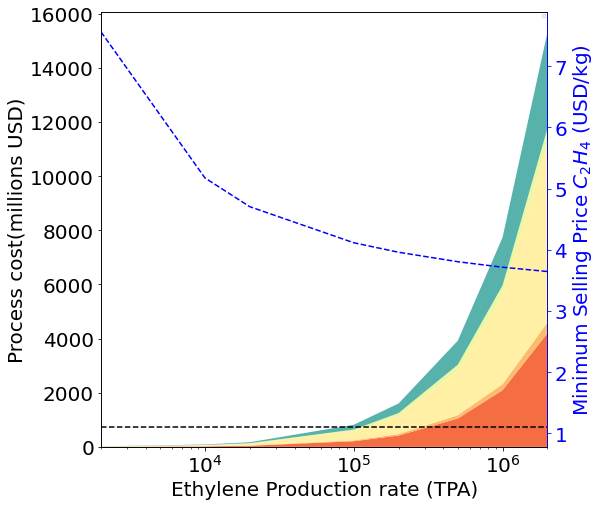

In [14]:
#----------------------------------------------------------------------------------------- basecase scenario

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# user to specify
source = ['Carbon Capture Unit', 'GO membrane concentrator', 'Electrolyzer', 'Cathode product separation', 'Anode product separation', 'Balance of Plant'] # list of units to be stacked
pct_max = 95 # for example, max percentile of color ramp
pct_min = 20 # for example, min percentile of color ramp
ramp = plt.cm.Spectral # for example

plt.rcParams.update({'font.size': 20})

# number of items in data source
n = len(source)

# list of values between 0.00 and 1.00; length equals length of data source
n_prop = list(i / 100.0 for i in (np.arange(pct_min, pct_max, (pct_max-pct_min)/n)))

# create list of colors
clr_lst = []
for j in n_prop:
    clr = ramp(j) 
    clr_lst.append(clr)

fig, ax = plt.subplots(figsize =(8,8))
ax2 = ax.twinx()

prodrate = [2000, 10000, 20000, 100000, 200000, 500000, 1000000, 2000000]

CCU = np.zeros(len(prodrate))
GO =  np.zeros(len(prodrate))
elec =  np.zeros(len(prodrate))
cath_sep =  np.zeros(len(prodrate))
zhf_sep =  np.zeros(len(prodrate))
anod_sep =  np.zeros(len(prodrate))
pervap =  np.zeros(len(prodrate))
distl =  np.zeros(len(prodrate))
bop =  np.zeros(len(prodrate))
soln = np.zeros((8,len(prodrate)))

soln = [4.19213877707648, 20.9606938853824, 41.9213877707648, 209.606938853824, 419.213877707648, 1048.03469426912, 2096.06938853824, 4192.13877707648,\
1.12237525915303, 4.40821317812487, 7.94580833214439, 31.2077593612010, 56.2520151226598, 122.570820190397, 220.934016798369, 398.233769691998,\
5.93350137949437, 32.6342575872190, 65.2685151744381, 329.309326561938, 658.618653123875, 1646.54663280969, 3293.09326561938, 6586.18653123875,\
0.00997136890709270, 0.0391633007425350, 0.0705918858231534, 0.277254936632458, 0.499752279802279, 1.08893959965376, 1.96281463588640, 3.53797519722386,\
4.49116089083582, 13.8559917628473, 22.5091250265300, 69.4444618078371, 112.812861034170, 214.247922569010, 348.046777042047, 565.403657392934,\
0.0189132911653500, 0.0742833724076605, 0.133895847493393, 0.525886003458402, 0.947910007794891, 2.06545679952544, 3.72298779214998, 6.71068893993928,\
3.19496228126620, 17.5722925469641, 35.1445850939282, 177.320406610274, 354.640813220548, 886.602033051370, 1773.20406610274, 3546.40813220548,\
7.56500000000000, 5.17500000000000, 4.70500000000000, 4.11500000000000, 3.96000000000000, 3.80500000000000, 3.71500000000000, 3.64500000000000]
soln = np.resize(soln,(8,8))

CCU= soln[0,:]
GO= soln[1,:]
elec=soln[2,:]
zhf_sep= soln[3,:]
distl = soln[4,:]
pervap= soln[5,:]
bop= soln[6,:]

for pp in range(len(prodrate)):
    cath_sep[pp] =distl[pp]+pervap[pp]+zhf_sep[pp] #5
    anod_sep[pp] = bop[pp]/10000
    
breakeven = soln[7,:]

ax.stackplot(prodrate, CCU, GO, elec, cath_sep, anod_sep, bop, colors =clr_lst)
ax.margins(x=0)
ax.legend(fontsize=4)
ax.set_xscale('log')
# ax.set_yscale('log')

ax2.plot(prodrate, breakeven, ls = '--', linewidth =1.5, c='blue')

ax2.margins(x=0)
ax2.yaxis.label.set_color('blue')
ax2.tick_params(axis='y', colors='blue')
ax2.axhline(y=1.1,color='k',ls="--", label='2-stack rate')
ax2.set_ylabel("Minimum Selling Price $C_{2}H_{4}$ (USD/kg)", c = 'blue', fontsize =20)
ax2.spines['right'].set_color('blue')

ax.set_xlabel("Ethylene Production rate (TPA)", fontsize =20)
ax.set_ylabel("Process cost(millions USD)", fontsize =20)

plt.show()

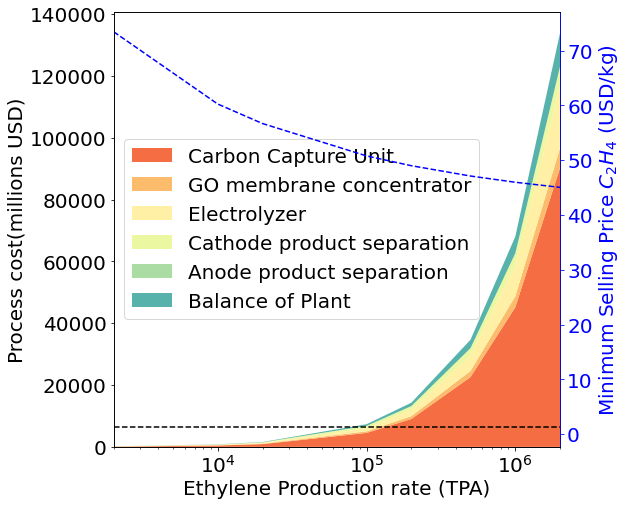

In [15]:
#----------------------------------------------------------------------------------------- pessimistic case scenario

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# user to specify
source = ['Carbon Capture Unit', 'GO membrane concentrator', 'Electrolyzer', 'Cathode product separation', 'Anode product separation', 'Balance of Plant'] # list of units to be stacked
pct_max = 95 # for example, max percentile of color ramp
pct_min = 20 # for example, min percentile of color ramp
ramp = plt.cm.Spectral # for example

plt.rcParams.update({'font.size': 20})

# number of items in data source
n = len(source)

# list of values between 0.00 and 1.00; length equals length of data source
n_prop = list(i / 100.0 for i in (np.arange(pct_min, pct_max, (pct_max-pct_min)/n)))

# create list of colors
clr_lst = []
for j in n_prop:
    clr = ramp(j) 
    clr_lst.append(clr)

fig, ax = plt.subplots(figsize =(8,8))
ax2 = ax.twinx()

prodrate = [2000, 10000, 20000, 100000, 200000, 500000, 1000000, 2000000]

CCU = np.zeros(len(prodrate))
GO =  np.zeros(len(prodrate))
elec =  np.zeros(len(prodrate))
cath_sep =  np.zeros(len(prodrate))
zhf_sep =  np.zeros(len(prodrate))
anod_sep =  np.zeros(len(prodrate))
pervap =  np.zeros(len(prodrate))
distl =  np.zeros(len(prodrate))
bop =  np.zeros(len(prodrate))
soln = np.zeros((8,len(prodrate)))

soln = [90.3115397079933, 451.557698539967, 903.115397079933, 4515.57698539967, 9031.15397079933, 22577.8849269983, 45155.7698539967, 90311.5397079933,\
18.0495051533044, 70.8907879308315, 127.780710835016, 501.868344673021, 904.618155612584, 1971.12563969097, 3552.95578927111, 6404.20609743282,\
20.6460427362102, 100.053899413942, 201.695955961438, 1008.47977980719, 2016.95955961438, 5040.81074190238, 10081.6214838048, 20163.2429676095,\
0.0303713263239423, 0.119285666577652, 0.215012524371900, 0.844477847911004, 1.52217210218878, 3.31675021115934, 5.97844532434384, 10.7761532285169,\
49.1667395492138, 151.687716107000, 246.417421811431, 760.239468109066, 1235.01265955236, 2345.46747799771, 3810.22315915852, 6189.72578335706,\
0.0300289564623475, 0.117940983216746, 0.212588731369737, 0.834958218744157, 1.50501296180777, 3.27936115219538, 5.91105151096815, 10.6546758175530,\
11.1170999348824, 53.8751766075069, 108.605514748466, 543.027573742332, 1086.05514748466, 2714.28270717821, 5428.56541435641, 10857.1308287128,\
73.4500000000000, 60.2700000000000, 56.7050000000000, 50.8000000000000, 49.0100000000000, 47.1250000000000, 45.9900000000000, 45.0550000000000]
soln = np.resize(soln,(8,8))

CCU= soln[0,:]
GO= soln[1,:]
elec=soln[2,:]
zhf_sep= soln[3,:]
distl = soln[4,:]
pervap= soln[5,:]
bop= soln[6,:]

for pp in range(len(prodrate)):
    cath_sep[pp] =distl[pp]+pervap[pp]+zhf_sep[pp] #5
    anod_sep[pp] = bop[pp]/10000
    
breakeven = soln[7,:]

ax.stackplot(prodrate, CCU, GO, elec, cath_sep, anod_sep, bop, labels=source, colors =clr_lst)
ax.margins(x=0)
ax.legend(fontsize=4)
ax.set_xscale('log')
ax.legend(loc='center left')
# ax.set_yscale('log')

ax2.plot(prodrate, breakeven, ls = '--', linewidth =1.5, c='blue')

ax2.margins(x=0)
ax2.yaxis.label.set_color('blue')
ax2.tick_params(axis='y', colors='blue')
ax2.axhline(y=1.3,color='k',ls="--", label='2-stack rate')
ax2.set_ylabel("Minimum Selling Price $C_{2}H_{4}$ (USD/kg)", c = 'blue', fontsize =20)
ax2.spines['right'].set_color('blue')

ax.set_xlabel("Ethylene Production rate (TPA)", fontsize =20)
ax.set_ylabel("Process cost(millions USD)", fontsize =20)

plt.show()

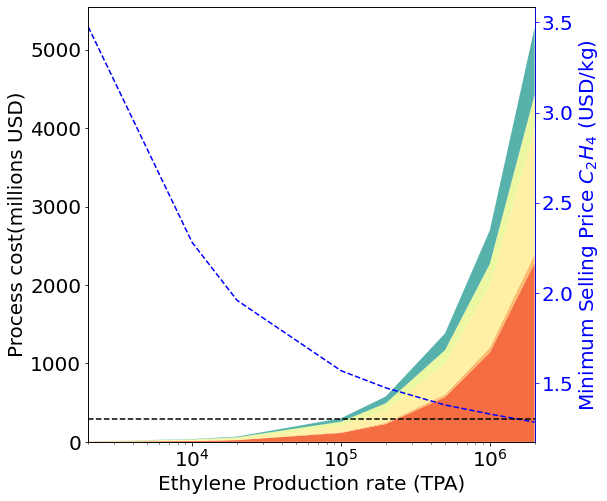

In [1]:
#----------------------------------------------------------------------------------------- optimistic case scenario

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# user to specify
source = ['Carbon Capture Unit', 'GO membrane concentrator', 'Electrolyzer', 'Cathode product separation', 'Anode product separation', 'Balance of Plant'] # list of units to be stacked
pct_max = 95 # for example, max percentile of color ramp
pct_min = 20 # for example, min percentile of color ramp
ramp = plt.cm.Spectral # for example

plt.rcParams.update({'font.size': 20})

# number of items in data source
n = len(source)

# list of values between 0.00 and 1.00; length equals length of data source
n_prop = list(i / 100.0 for i in (np.arange(pct_min, pct_max, (pct_max-pct_min)/n)))

# create list of colors
clr_lst = []
for j in n_prop:
    clr = ramp(j) 
    clr_lst.append(clr)

fig, ax = plt.subplots(figsize =(8,8))
ax2 = ax.twinx()

prodrate = [2000, 10000, 20000, 100000, 200000, 500000, 1000000, 2000000]

CCU = np.zeros(len(prodrate))
GO =  np.zeros(len(prodrate))
elec =  np.zeros(len(prodrate))
cath_sep =  np.zeros(len(prodrate))
zhf_sep =  np.zeros(len(prodrate))
anod_sep =  np.zeros(len(prodrate))
pervap =  np.zeros(len(prodrate))
distl =  np.zeros(len(prodrate))
bop =  np.zeros(len(prodrate))
soln = np.zeros((8,len(prodrate)))

soln = [2.27957619399261, 11.3978809699630, 22.7957619399261, 113.978809699630, 227.957619399261, 569.894048498152, 1139.78809699630, 2279.57619399261,\
0.315654472435105, 1.23975666228827, 2.23466253082432, 8.77680502729128, 15.8201991821826, 34.4715613317550, 62.1350211943236, 111.998433191436,\
0, 8.02135629475695, 16.0427125895139, 80.2135629475695, 160.427125895139, 397.057136590469, 794.114273180938, 1588.22854636188,\
0.00193818817744029, 0.00761237972398429, 0.0137213214956203, 0.0538915213472596, 0.0971395170900383, 0.211663000101642, 0.381522753518402, 0.687695116210036,\
3.49304804155859, 10.7766446287473, 17.5067108487591, 54.0111670926607, 87.7413998020214, 166.633595306002, 270.697074201510, 439.748694413596,\
0.0126193855710628, 0.0495635851917983, 0.0893384081655190, 0.350883311954977, 0.632467494443686, 1.37812057699068, 2.48406361509270, 4.47752696451406,\
0, 4.31919185102297, 8.63838370204595, 43.1919185102297, 86.3838370204595, 213.799996625637, 427.599993251274, 855.199986502548,\
3.47500000000000, 2.28000000000000, 1.96000000000000, 1.57000000000000, 1.47500000000000, 1.38000000000000, 1.33000000000000, 1.28500000000000]
soln = np.resize(soln,(8,8))

CCU= soln[0,:]
GO= soln[1,:]
elec=soln[2,:]
zhf_sep= soln[3,:]
distl = soln[4,:]
pervap= soln[5,:]
bop= soln[6,:]

for pp in range(len(prodrate)):
    cath_sep[pp] =distl[pp]+pervap[pp]+zhf_sep[pp] #5
    anod_sep[pp] = bop[pp]/10000
    
breakeven = soln[7,:]

ax.stackplot(prodrate, CCU, GO, elec, cath_sep, anod_sep, bop, labels=source, colors =clr_lst)
ax.margins(x=0)
#ax.legend(fontsize=4)
ax.set_xscale('log')
#ax.legend(loc='center left')
# ax.set_yscale('log')

ax2.plot(prodrate, breakeven, ls = '--', linewidth =1.5, c='blue')

ax2.margins(x=0)
ax2.yaxis.label.set_color('blue')
ax2.tick_params(axis='y', colors='blue')
ax2.axhline(y=1.3,color='k',ls="--", label='2-stack rate')
ax2.set_ylabel("Minimum Selling Price $C_{2}H_{4}$ (USD/kg)", c = 'blue', fontsize =20)
ax2.spines['right'].set_color('blue')

ax.set_xlabel("Ethylene Production rate (TPA)", fontsize =20)
ax.set_ylabel("Process cost(millions USD)", fontsize =20)

plt.show()